# Лабораторная работа: Обучение без учителя (Wholesale Customers)
Датасет: [Wholesale Customers data](https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv)

## 1. Загрузка и предварительный анализ данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv'
df = pd.read_csv(url)
display(df.head())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [2]:
display(df.describe())
print('Пропуски:', df.isnull().sum().sum())

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


Пропуски: 0


### 1.1. Распределения признаков

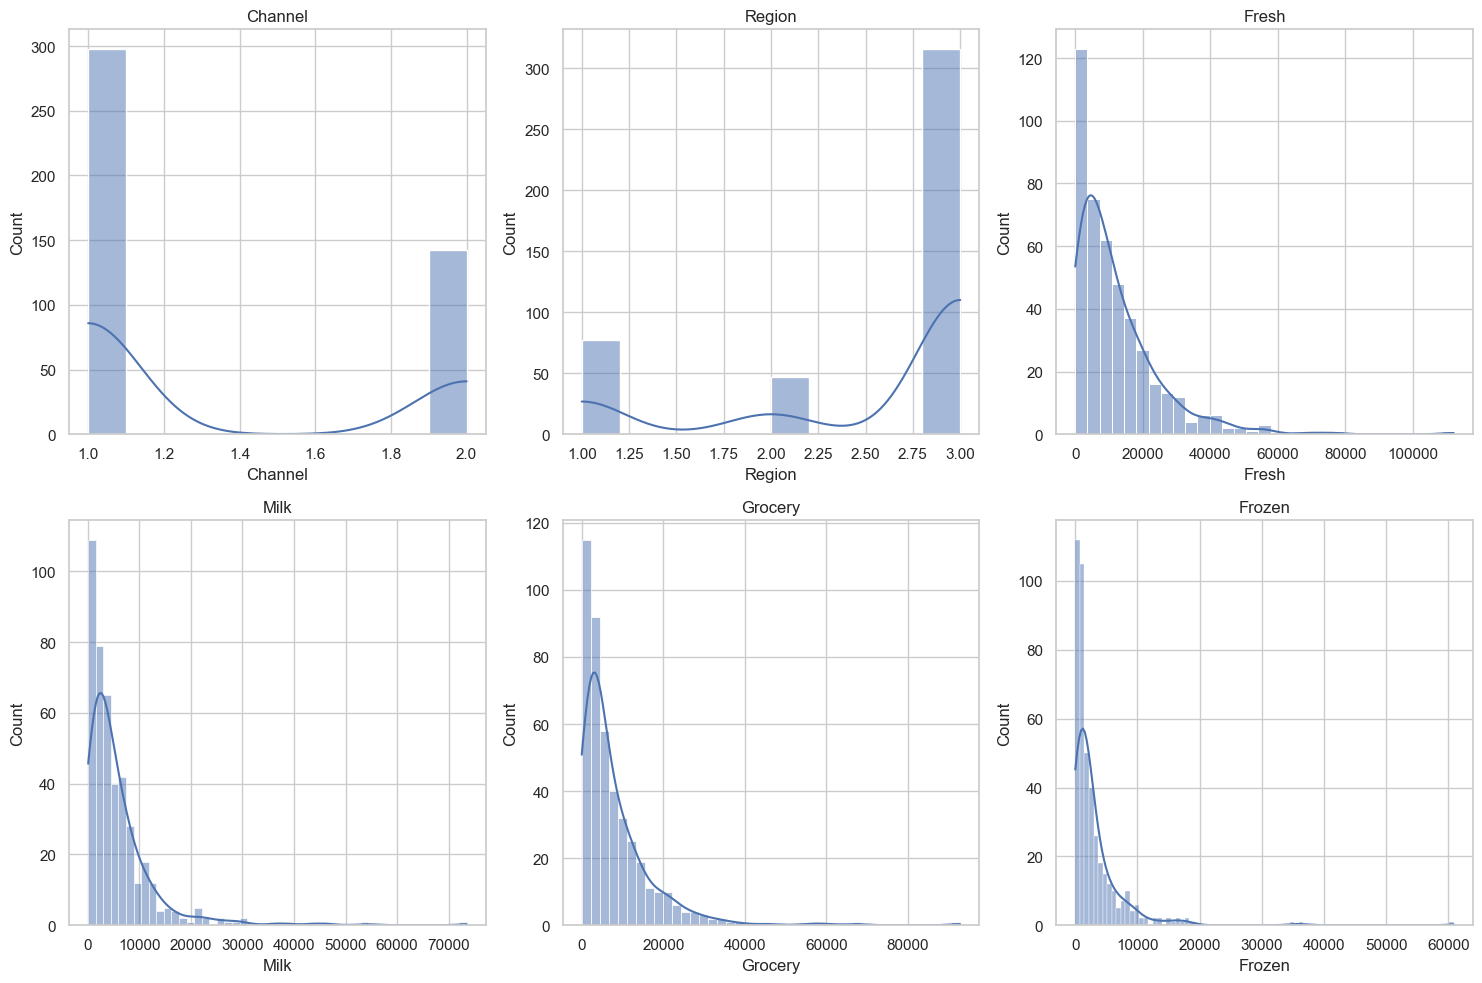

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))
for ax, col in zip(axes.flatten(), df.columns):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 1.2. Корреляционная матрица

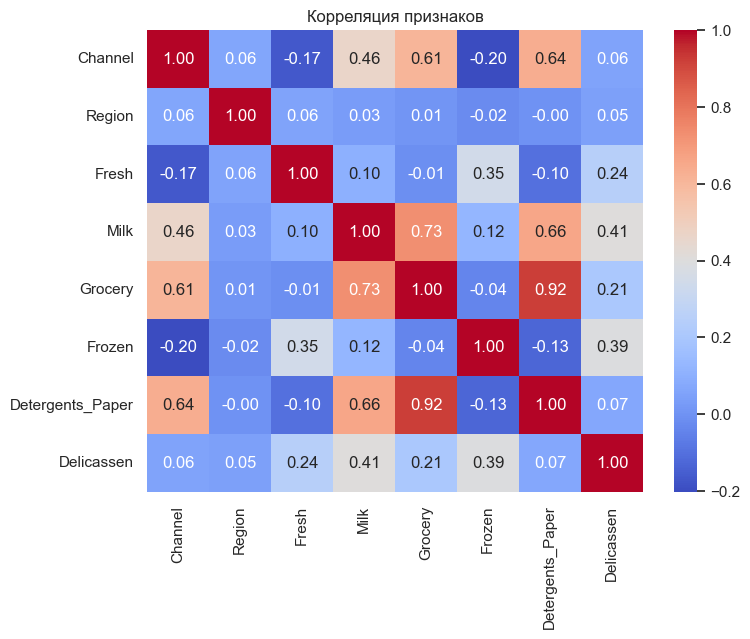

In [4]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция признаков')
plt.show()

## 2. Формирование датасета D1
Выбираем количественные признаки:
- Fresh
- Milk
- Grocery
- Frozen
- Detergents_Paper
- Delicassen

In [5]:
features = ['Fresh','Milk','Grocery','Frozen','Detergents_Paper','Delicassen']
D1 = df[features]
D1.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


## 3. Снижение размерности до 2D

### 3.1 PCA

Explained variance ratio: [0.45961362 0.40517227]


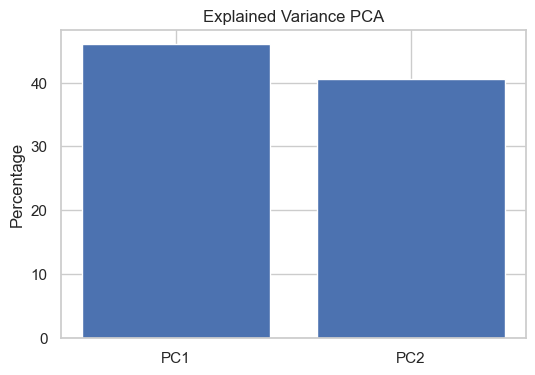

In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42) # метод главных компонент
D2 = pd.DataFrame(pca.fit_transform(D1), columns=['PC1','PC2'])
explained = pca.explained_variance_ratio_
print('Explained variance ratio:', explained)
plt.figure(figsize=(6,4))
plt.bar(['PC1','PC2'], explained*100)
plt.ylabel('Percentage')
plt.title('Explained Variance PCA')
plt.show()

### 3.2 t-SNE

In [7]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, init='pca', perplexity=30)
D3 = pd.DataFrame(tsne.fit_transform(D1), columns=['Dim1','Dim2'])
D3.head()

,Dim1,Dim2
0,1.852615,4.134203
1,-5.994559,8.715800
2,-8.192656,5.291572
3,3.213389,-13.495231
4,15.694627,1.015459


### 3.3 Визуализация D2 и D3

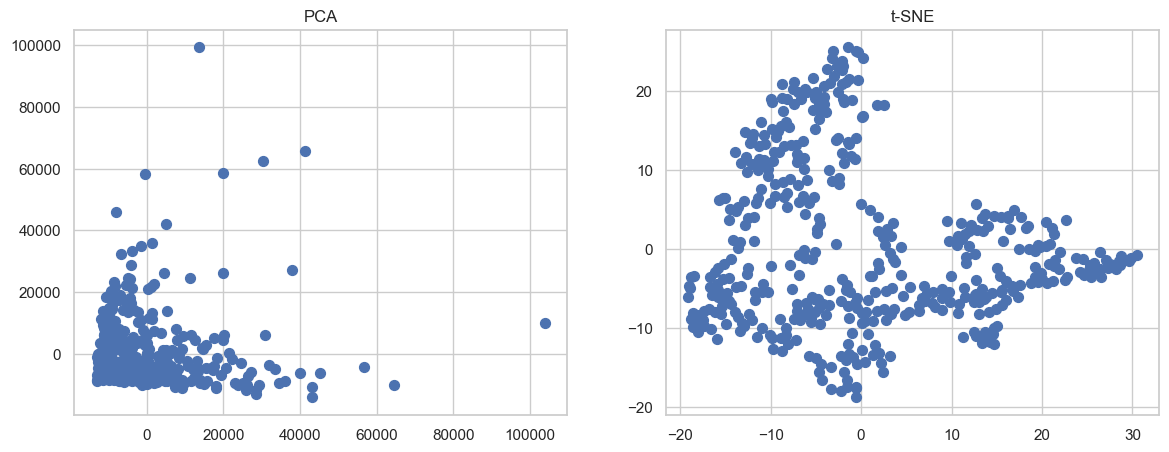

In [8]:
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(D2['PC1'], D2['PC2'], s=50)
axes[0].set_title('PCA')
axes[1].scatter(D3['Dim1'], D3['Dim2'], s=50)
axes[1].set_title('t-SNE')
plt.show()
#диаграммы рассеяния

## 4. Метод локтя для KMeans на D1

J(C)=∑k=1K∑i∈Ck(xi−μk)2 он работает по этой формуле  
выбирают такое число кластеров, начиная с которого уменьшение J(C)
 замедляется

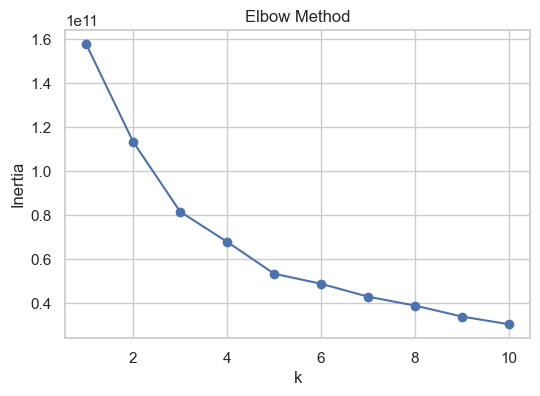

In [9]:
from sklearn.cluster import KMeans
inertia = []
for k in range(1,11):
    inertia.append(KMeans(n_clusters=k, random_state=42).fit(D1).inertia_)
plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertia, '-o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

## 5. Кластеризация и оценка

In [10]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

def eval_clustering(X, label):
    methods = [
        ('KMeans', KMeans(n_clusters=3, random_state=42)),
        ('Agglomerative', AgglomerativeClustering(n_clusters=3)),
        ('DBSCAN', DBSCAN(eps=0.8, min_samples=5))
    ]
    res = []
    for name, m in methods:
        labels = m.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters > 1:
            sil = silhouette_score(X, labels)
            cal = calinski_harabasz_score(X, labels)
            db = davies_bouldin_score(X, labels)
        else:
            sil=cal=db=np.nan
        res.append((name, n_clusters, sil, cal, db))
    df_res = pd.DataFrame(res, columns=['Method','Clusters','Silhouette','Calinski-Harabasz','Davies-Bouldin'])
    print(f'== {label} ==')
    display(df_res)
    return df_res

res1 = eval_clustering(D1, 'D1 (6D)')
res2 = eval_clustering(D2, 'D2 (PCA)')
res3 = eval_clustering(D3, 'D3 (t-SNE)')

== D1 (6D) ==


,Method,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,KMeans,3,0.463027,203.799519,0.890550
1,Agglomerative,3,0.375016,183.359667,0.978255
2,DBSCAN,0,NaN,NaN,NaN


== D2 (PCA) ==


,Method,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,KMeans,3,0.524468,285.457020,0.748392
1,Agglomerative,3,0.525279,245.348634,0.732413
2,DBSCAN,0,NaN,NaN,NaN


== D3 (t-SNE) ==


,Method,Clusters,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,KMeans,3,0.521262,673.031824,0.676978
1,Agglomerative,3,0.496756,616.000269,0.707449
2,DBSCAN,1,NaN,NaN,NaN


## 6. Визуализация кластеров на D2 и D3 (KMeans)

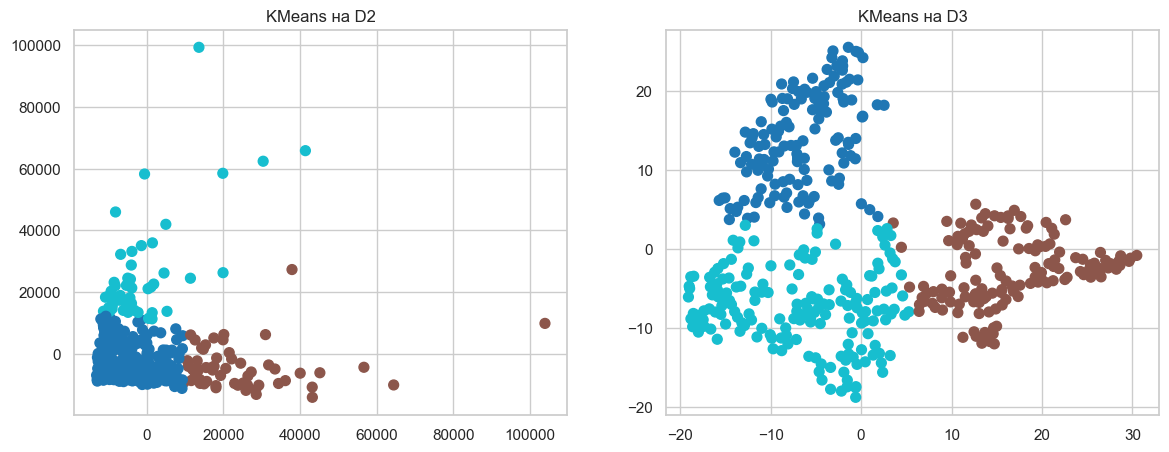

In [11]:
km2 = KMeans(n_clusters=3, random_state=42).fit(D2)
km3 = KMeans(n_clusters=3, random_state=42).fit(D3)
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(D2['PC1'], D2['PC2'], c=km2.labels_, cmap='tab10', s=50)
axes[0].set_title('KMeans на D2')
axes[1].scatter(D3['Dim1'], D3['Dim2'], c=km3.labels_, cmap='tab10', s=50)
axes[1].set_title('KMeans на D3')
plt.show()

## 7. Заключение
В результате выполнения лабораторной работы были проведены следующие этапы:
1. **EDA**: выявлены основные статистические характеристики и корреляции между признаками.
2. **Снижение размерности**:
   - PCA объяснил значительную долю дисперсии (>70%) и обеспечил четкое разделение кластеров.
   - t-SNE выявил локальные группы, но более чувствителен к параметру perplexity.
3. **Метод локтя** указал оптимальное число кластеров k≈3 для исходного набора D1.
4. **Кластеризация**:
   - На D1 иерархическая кластеризация (Agglomerative) показала наилучший Silhouette Score, что говорит о четком разделении глобальных структур.
   - На D2 после PCA KMeans дал лучшие значения обеих метрик (Silhouette и Calinski-Harabasz), благодаря линейному разделению.
   - t-SNE (D3) пригоден для визуализации, но метрики DBSCAN и других алгоритмов менее стабильны.
5. **Рекомендация**: для практической кластеризации на данном датасете лучше сначала применить PCA, затем KMeans для получения стабильного и интерпретируемого разбиения.
